## ING SISTEMAS
### GRUPO 10
- Condori Romero Said
- Janko Sanga Helen


# Ames Housing - Clasificacion con PyTorch (Organizado)

Este cuaderno sigue un flujo completo y ordenado:
1. Carga de dataset
2. Exploracion (tipos, nulos, balance de clases)
3. Definicion del target
4. Split 80/20 con grafica
5. Normalizacion
6. Modelo con PyTorch
7. Entrenamiento con regularizacion y optimizacion
8. Metricas con graficas
9. Comparacion Train vs Test

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

sns.set_style('whitegrid')

## 1. Carga de dataset
En esta seccion se carga el archivo principal de Ames Housing. Este dataset contiene informacion de propiedades y su precio de venta (`SalePrice`), que sera nuestra variable objetivo base.

In [2]:
df = pd.read_csv('Datasets Primer Parcial/1-Ames Housing Dataset/train.csv')
print('Shape:', df.shape)
df.head()

Shape: (2197, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,534,531363010,20,RL,80.0,9605,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,159000
1,803,906203120,20,RL,90.0,14684,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,271900
2,956,916176030,20,RL,NaN,14375,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2009,COD,Abnorml,137500
3,460,528180130,120,RL,48.0,6472,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,248500
4,487,528290030,80,RL,61.0,9734,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,167000


## 2. Exploracion (tipos, nulos y distribucion)
Aqui se revisa la estructura del dataset: tipos de datos, valores faltantes y forma de la distribucion del precio. Esta etapa permite entender la calidad y naturaleza de los datos antes del modelado.

Tipos de datos:
str        43
int64      28
float64    11
Name: count, dtype: int64

Top 15 columnas con nulos:
Pool QC           2185
Misc Feature      2117
Alley             2054
Fence             1778
Mas Vnr Type      1329
Fireplace Qu      1066
Lot Frontage       362
Garage Qual        122
Garage Yr Blt      122
Garage Cond        122
Garage Finish      122
Garage Type        120
Bsmt Exposure       69
BsmtFin Type 2      68
Bsmt Qual           67
dtype: int64


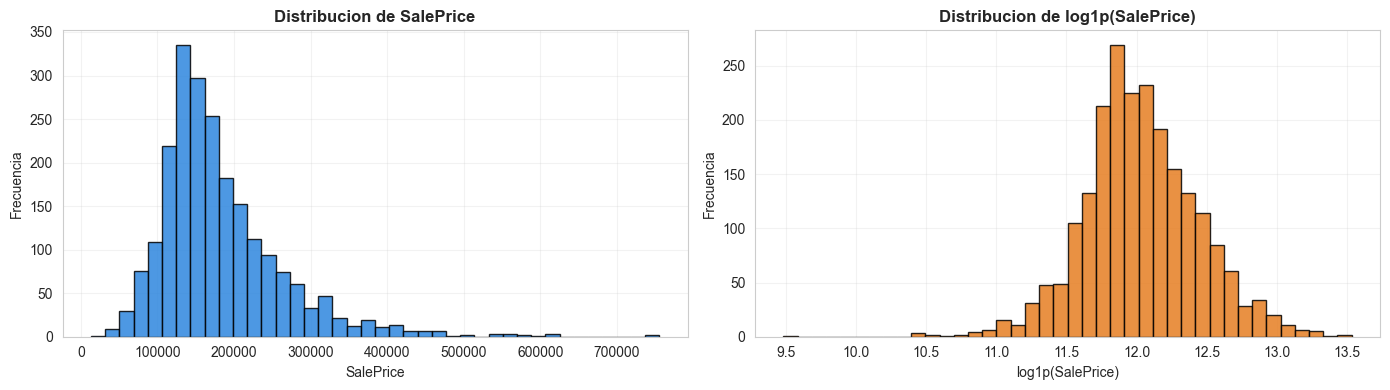

In [3]:
print('Tipos de datos:')
print(df.dtypes.value_counts())

print('\nTop 15 columnas con nulos:')
print(df.isna().sum().sort_values(ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['SalePrice'], bins=40, color='#2e86de', edgecolor='black', alpha=0.85)
axes[0].set_title('Distribucion de SalePrice', fontweight='bold')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(alpha=0.25)

axes[1].hist(np.log1p(df['SalePrice']), bins=40, color='#e67e22', edgecolor='black', alpha=0.85)
axes[1].set_title('Distribucion de log1p(SalePrice)', fontweight='bold')
axes[1].set_xlabel('log1p(SalePrice)')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 3. Definicion del target
Se transforma la variable objetivo original (`SalePrice`) en una variable de clasificacion multiclase (`PRICE_CLASS`) usando terciles: Bajo, Medio y Alto.

Rangos (USD): Bajo <= 140,000 | Medio <= 192,000 | Alto > 192,000
Balance global: {1: 720, 2: 730, 0: 747}


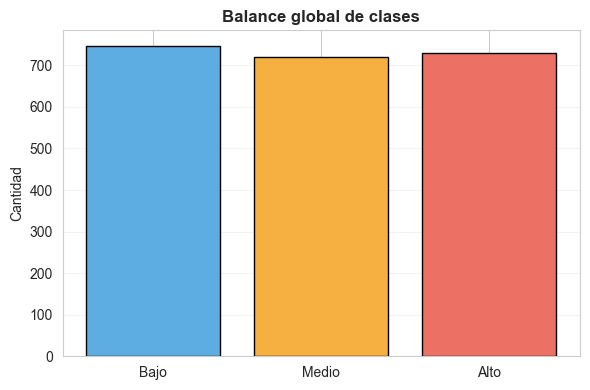

In [4]:
# Terciles para clases de precio
q1, q2 = df['SalePrice'].quantile([1/3, 2/3]).values
bins = [-np.inf, q1, q2, np.inf]
class_names = ['Bajo', 'Medio', 'Alto']

df['PRICE_CLASS'] = pd.cut(df['SalePrice'], bins=bins, labels=[0, 1, 2], include_lowest=True).astype(int)

print(f'Rangos (USD): Bajo <= {q1:,.0f} | Medio <= {q2:,.0f} | Alto > {q2:,.0f}')
print('Balance global:', dict(Counter(df['PRICE_CLASS'])))

fig, ax = plt.subplots(figsize=(6, 4))
dist_global = Counter(df['PRICE_CLASS'])
ax.bar([class_names[i] for i in range(3)], [dist_global[i] for i in range(3)],
       color=['#5dade2', '#f5b041', '#ec7063'], edgecolor='black')
ax.set_title('Balance global de clases', fontweight='bold')
ax.set_ylabel('Cantidad')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

In [5]:
# Interpretacion automatica de clases (con rangos reales)
print('=== Significado de clases (PRICE_CLASS) ===')
print(f'Clase 0 (Bajo) : SalePrice <= {q1:,.0f} USD')
print(f'Clase 1 (Medio): {q1:,.0f} < SalePrice <= {q2:,.0f} USD')
print(f'Clase 2 (Alto) : SalePrice > {q2:,.0f} USD')

print('\nInterpretacion:')
print('- Clase Bajo: viviendas en el tercil inferior de precios.')
print('- Clase Medio: viviendas en el tercil intermedio.')
print('- Clase Alto: viviendas en el tercil superior.')

=== Significado de clases (PRICE_CLASS) ===
Clase 0 (Bajo) : SalePrice <= 140,000 USD
Clase 1 (Medio): 140,000 < SalePrice <= 192,000 USD
Clase 2 (Alto) : SalePrice > 192,000 USD

Interpretacion:
- Clase Bajo: viviendas en el tercil inferior de precios.
- Clase Medio: viviendas en el tercil intermedio.
- Clase Alto: viviendas en el tercil superior.


## 4. Preprocesamiento de features
Se preparan las variables predictoras: imputacion de nulos, codificacion de categoricas y conversion final a matriz numerica para entrenar redes neuronales.

In [6]:
target_reg = 'SalePrice'
id_cols = [col for col in ['Id', 'Order', 'PID'] if col in df.columns]
X_df = df.drop(columns=[target_reg, 'PRICE_CLASS'] + id_cols).copy()
y_cls = df['PRICE_CLASS'].values.astype(np.int64)

num_cols = X_df.select_dtypes(include=[np.number]).columns
cat_cols = X_df.select_dtypes(include=['object', 'str']).columns

X_df[num_cols] = X_df[num_cols].fillna(X_df[num_cols].median())
X_df[cat_cols] = X_df[cat_cols].fillna('None')

X_df = pd.get_dummies(X_df, columns=cat_cols, drop_first=True)
X_cls = X_df.values.astype(np.float32)

print('Features listas:', X_cls.shape)

Features listas: (2197, 276)


## 5. Split 80/20 y verificacion de clases
Se divide el dataset en entrenamiento y prueba con estratificacion para mantener proporciones de clases. Se grafica el balance para confirmar representatividad.

Train: (1757, 276) (1757,)
Test : (440, 276) (440,)


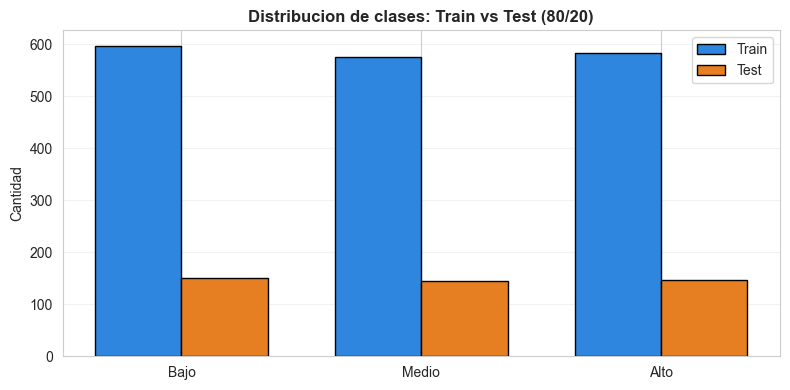

In [7]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print('Train:', X_train_cls.shape, y_train_cls.shape)
print('Test :', X_test_cls.shape, y_test_cls.shape)

train_dist = Counter(y_train_cls)
test_dist = Counter(y_test_cls)

x = np.arange(len(class_names))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, [train_dist[i] for i in range(3)], width, label='Train', color='#2e86de', edgecolor='black')
ax.bar(x + width/2, [test_dist[i] for i in range(3)], width, label='Test', color='#e67e22', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_title('Distribucion de clases: Train vs Test (80/20)', fontweight='bold')
ax.set_ylabel('Cantidad')
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Normalizacion
Se aplica normalizacion usando solo estadisticas de train (sin leakage). Luego se crean tensores y dataloaders para entrenamiento, validacion y prueba en PyTorch.

In [8]:
mu = X_train_cls.mean(axis=0)
sigma = X_train_cls.std(axis=0)
sigma[sigma == 0] = 1.0

X_train_cls = (X_train_cls - mu) / sigma
X_test_cls = (X_test_cls - mu) / sigma

Xtr_np, Xval_np, ytr_np, yval_np = train_test_split(
    X_train_cls, y_train_cls, test_size=0.15, random_state=42, stratify=y_train_cls
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
Xtr = torch.tensor(Xtr_np, dtype=torch.float32, device=device)
ytr = torch.tensor(ytr_np, dtype=torch.long, device=device)
Xval = torch.tensor(Xval_np, dtype=torch.float32, device=device)
yval = torch.tensor(yval_np, dtype=torch.long, device=device)
Xte = torch.tensor(X_test_cls, dtype=torch.float32, device=device)
yte = torch.tensor(y_test_cls, dtype=torch.long, device=device)

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(Xval, yval), batch_size=256, shuffle=False)
test_loader = DataLoader(TensorDataset(Xte, yte), batch_size=256, shuffle=False)

print('Normalizacion y tensores listos.')

Normalizacion y tensores listos.


## 7. Modelo PyTorch + Regularizacion + Optimizacion

In [9]:
class MLPClassifier(nn.Module):
    def __init__(self, d_in, d_out=3, p=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 128), nn.ReLU(), nn.Dropout(p),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(p),
            nn.Linear(64, d_out)
        )

    def forward(self, x):
        return self.net(x)

model_cls = MLPClassifier(d_in=Xtr.shape[1], d_out=3, p=0.25).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cls.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=6)

print(model_cls)

MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=276, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.25, inplace=False)
    (6): Linear(in_features=64, out_features=3, bias=True)
  )
)


## 7. Modelo con PyTorch
Se define una red neuronal MLP para clasificacion multiclase del objetivo `PRICE_CLASS`, con regularizacion por Dropout para mejorar generalizacion.

In [10]:
best_state, best_val, patience, wait = None, 0.0, 18, 0
history = {'tr_loss': [], 'va_loss': [], 'tr_acc': [], 'va_acc': []}

for epoch in range(1, 201):
    model_cls.train()
    tr_loss, tr_acc = [], []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model_cls(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        tr_loss.append(loss.item())
        tr_acc.append((logits.argmax(1) == yb).float().mean().item())

    model_cls.eval()
    va_loss, va_acc = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model_cls(xb)
            va_loss.append(criterion(logits, yb).item())
            va_acc.append((logits.argmax(1) == yb).float().mean().item())

    tr_l, tr_a = float(np.mean(tr_loss)), float(np.mean(tr_acc))
    va_l, va_a = float(np.mean(va_loss)), float(np.mean(va_acc))

    history['tr_loss'].append(tr_l)
    history['va_loss'].append(va_l)
    history['tr_acc'].append(tr_a)
    history['va_acc'].append(va_a)

    scheduler.step(va_a)

    if va_a > best_val:
        best_val = va_a
        best_state = {k: v.detach().clone() for k, v in model_cls.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch % 20 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | Loss tr/va: {tr_l:.4f}/{va_l:.4f} | Acc tr/va: {tr_a:.4f}/{va_a:.4f} | wait {wait}/{patience}')

    if wait >= patience:
        print(f'Early stopping en epoch {epoch} (best_val_acc={best_val:.4f})')
        break

model_cls.load_state_dict(best_state)
print('Entrenamiento finalizado.')

Epoch   1 | Loss tr/va: 0.9715/0.7023 | Acc tr/va: 0.5699/0.8418 | wait 0/18
Epoch  20 | Loss tr/va: 0.1026/0.4043 | Acc tr/va: 0.9687/0.8379 | wait 18/18
Early stopping en epoch 20 (best_val_acc=0.8516)
Entrenamiento finalizado.


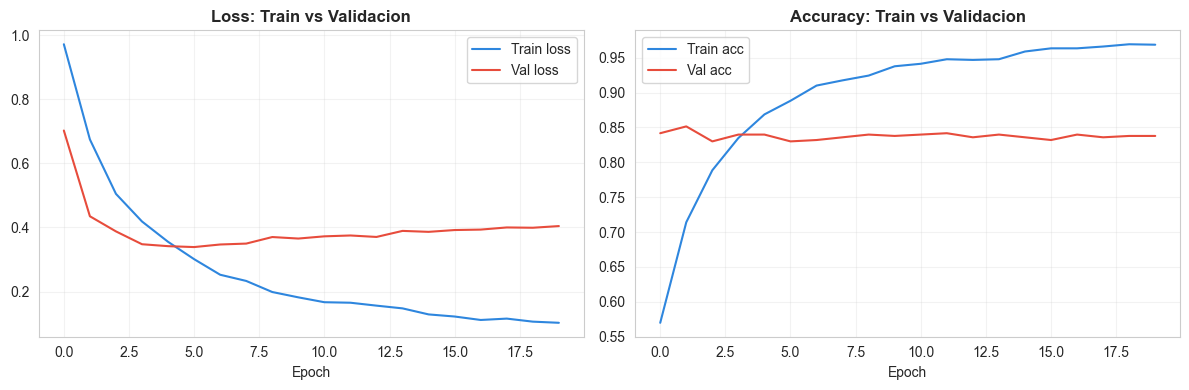

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['tr_loss'], label='Train loss', color='#2e86de')
axes[0].plot(history['va_loss'], label='Val loss', color='#e74c3c')
axes[0].set_title('Loss: Train vs Validacion', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(history['tr_acc'], label='Train acc', color='#2e86de')
axes[1].plot(history['va_acc'], label='Val acc', color='#e74c3c')
axes[1].set_title('Accuracy: Train vs Validacion', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Entrenamiento con regularizacion y optimizacion
Se entrena la red con Adam, penalizacion L2 (`weight_decay`), scheduler de learning rate y early stopping para reducir sobreajuste y estabilizar el aprendizaje.

In [12]:
def infer_loader(loader):
    y_true_list, y_pred_list, y_prob_list = [], [], []
    model_cls.eval()
    with torch.no_grad():
        for xb, yb in loader:
            logits = model_cls(xb)
            prob = torch.softmax(logits, dim=1)
            pred = logits.argmax(dim=1)
            y_true_list.append(yb.cpu().numpy())
            y_pred_list.append(pred.cpu().numpy())
            y_prob_list.append(prob.cpu().numpy())
    y_true = np.concatenate(y_true_list)
    y_pred = np.concatenate(y_pred_list)
    y_prob = np.concatenate(y_prob_list)
    return y_true, y_pred, y_prob

y_true_tr, y_pred_tr, y_prob_tr = infer_loader(train_loader)
y_true_te, y_pred_te, y_prob_te = infer_loader(test_loader)

def metrics_pack(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1': f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

m_train = metrics_pack(y_true_tr, y_pred_tr)
m_test = metrics_pack(y_true_te, y_pred_te)

print('=== Metricas Train ===')
for k, v in m_train.items():
    print(f'{k}: {v:.4f}')

print('\n=== Metricas Test ===')
for k, v in m_test.items():
    print(f'{k}: {v:.4f}')

print('\nMetricas por clase (Test):')
for i, name in enumerate(class_names):
    p_i = precision_score(y_true_te, y_pred_te, labels=[i], average='micro', zero_division=0)
    r_i = recall_score(y_true_te, y_pred_te, labels=[i], average='micro', zero_division=0)
    f1_i = f1_score(y_true_te, y_pred_te, labels=[i], average='micro', zero_division=0)
    print(f'{name}: Precision={p_i:.4f} | Recall={r_i:.4f} | F1={f1_i:.4f}')

=== Metricas Train ===
Accuracy: 0.7555
Precision: 0.7821
Recall: 0.7555
F1: 0.7226

=== Metricas Test ===
Accuracy: 0.7273
Precision: 0.7196
Recall: 0.7273
F1: 0.7002

Metricas por clase (Test):
Bajo: Precision=0.7107 | Recall=0.9333 | F1=0.8069
Medio: Precision=0.6800 | Recall=0.3542 | F1=0.4658
Alto: Precision=0.7679 | Recall=0.8836 | F1=0.8217


In [18]:
# Interpretacion automatica de metricas segun resultados obtenidos
def interpretar_score(nombre, valor):
    if valor >= 0.90:
        nivel = 'excelente'
    elif valor >= 0.80:
        nivel = 'muy bueno'
    elif valor >= 0.70:
        nivel = 'bueno/aceptable'
    elif valor >= 0.60:
        nivel = 'moderado'
    else:
        nivel = 'bajo'
    print(f'- {nombre}: {valor:.4f} -> {nivel}')

print('=== Interpretacion de metricas (TEST) ===')
print('Problema: clasificar si una casa es Barata (0), Media (1) o Cara (2).\n')
interpretar_score('Accuracy', m_test['Accuracy'])
interpretar_score('Precision', m_test['Precision'])
interpretar_score('Recall', m_test['Recall'])
interpretar_score('F1', m_test['F1'])

gap_acc = m_train['Accuracy'] - m_test['Accuracy']
print(f'\nBrecha de generalizacion (Train - Test) en Accuracy: {gap_acc:.4f}')
if gap_acc < 0.05:
    print('Diagnostico: buena generalizacion (sin sobreajuste relevante).')
elif gap_acc < 0.12:
    print('Diagnostico: sobreajuste leve a moderado.')
else:
    print('Diagnostico: sobreajuste marcado (el modelo aprende mejor train que test).')

print('\nComo leer los resultados:')
print('- Si Accuracy > 0.70: el modelo acierta bien al clasificar casas baratas/medias/caras.')
print('- Recall alto: detecta bien las casas de cada clase real.')
print('- Precision alta: cuando predice una clase, suele acertar.')
print('- F1 alto: hay buen equilibrio entre precision y recall.')

=== Interpretacion de metricas (TEST) ===
Problema: clasificar si una casa es Barata (0), Media (1) o Cara (2).

- Accuracy: 0.7273 -> bueno/aceptable
- Precision: 0.7196 -> bueno/aceptable
- Recall: 0.7273 -> bueno/aceptable
- F1: 0.7002 -> bueno/aceptable

Brecha de generalizacion (Train - Test) en Accuracy: 0.0283
Diagnostico: buena generalizacion (sin sobreajuste relevante).

Como leer los resultados:
- Si Accuracy > 0.70: el modelo acierta bien al clasificar casas baratas/medias/caras.
- Recall alto: detecta bien las casas de cada clase real.
- Precision alta: cuando predice una clase, suele acertar.
- F1 alto: hay buen equilibrio entre precision y recall.


### Interpretacion de metricas (en lenguaje del problema)
Aqui la pregunta real es: **que tan bien clasifica el modelo si una casa es barata, media o cara**.

- **Accuracy**: porcentaje total de casas clasificadas correctamente.
- **Precision**: cuando el modelo dice “barata/media/cara”, que tan seguido acierta.
- **Recall**: de todas las casas que realmente son de una clase, cuantas detecta.
- **F1**: equilibrio entre precision y recall.

Referencia rapida para interpretar Accuracy en este problema:
- **>= 0.80**: muy buen desempeño.
- **0.70 a 0.79**: bueno/aceptable.
- **0.60 a 0.69**: regular.
- **< 0.60**: bajo, hay bastante confusion entre clases.

La comparacion **Train vs Test** indica generalizacion:
- Si son parecidos, el modelo generaliza bien.
- Si Train es mucho mayor que Test, hay sobreajuste.

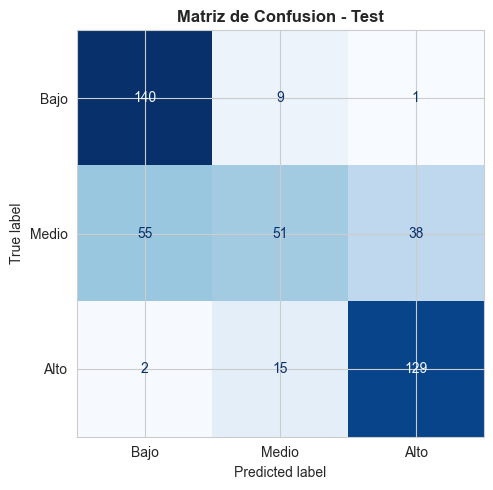

In [14]:
cm = confusion_matrix(y_true_te, y_pred_te)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusion - Test', fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretacion de matriz de confusion
La matriz de confusion responde: **en que se equivoca el modelo al decidir si una casa es barata, media o cara**.

- **Diagonal**: aciertos (clasifico bien la clase real).
- **Fuera de diagonal**: errores (confundio una clase con otra).

Lectura practica:
- Si hay muchos errores `Media -> Barata` o `Media -> Cara`, el modelo no separa bien la clase intermedia.
- Si hay errores `Cara -> Media`, el modelo subestima casas caras.
- Si hay errores `Barata -> Media`, el modelo sobreestima casas baratas.

## 10. Curva ROC y comparacion Train vs Test
En esta seccion se evalua la capacidad de separacion de clases con ROC/AUC y se compara el rendimiento entre entrenamiento y prueba para validar generalizacion.

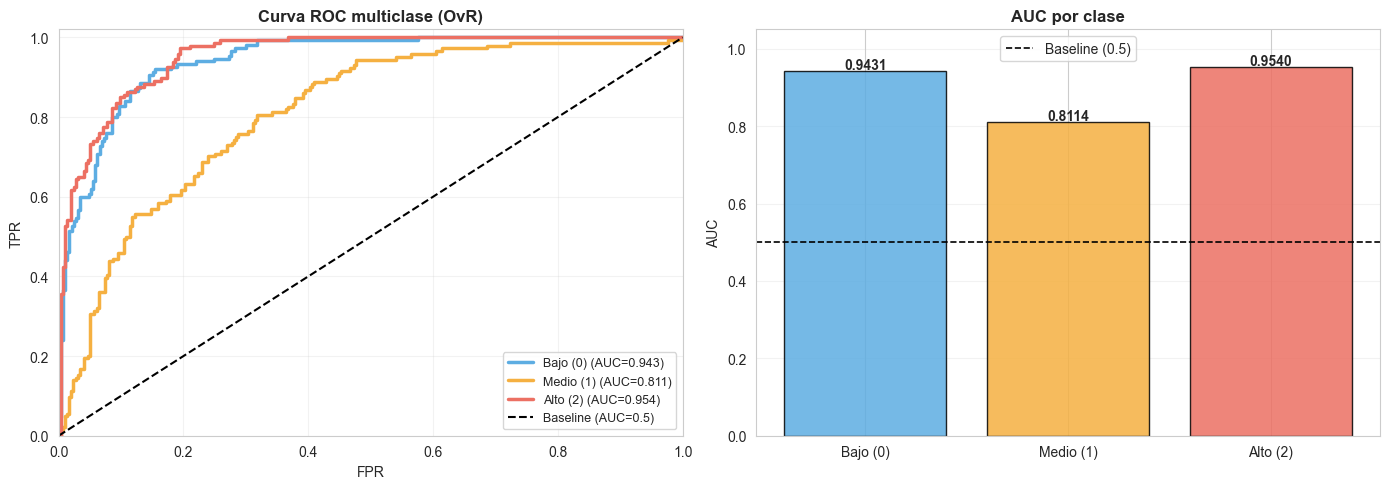

=== AUC ROC (Test) ===
Bajo (0): 0.9431
Medio (1): 0.8114
Alto (2): 0.9540
AUC macro   : 0.9028
AUC weighted: 0.9036


In [19]:
y_true_bin = label_binarize(y_true_te, classes=[0, 1, 2])
class_names_roc = ['Bajo (0)', 'Medio (1)', 'Alto (2)']
colors_roc = ['#5dade2', '#f5b041', '#ec7063']
auc_scores = []

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, color) in enumerate(zip(class_names_roc, colors_roc)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob_te[:, i])
    auc_i = auc(fpr, tpr)
    auc_scores.append(auc_i)
    axes[0].plot(fpr, tpr, lw=2.5, color=color, label=f'{name} (AUC={auc_i:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Baseline (AUC=0.5)')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.02)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC multiclase (OvR)', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.25)

bars = axes[1].bar(class_names_roc, auc_scores, color=colors_roc, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, auc_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[1].axhline(0.5, color='black', ls='--', lw=1.2, label='Baseline (0.5)')
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('AUC')
axes[1].set_title('AUC por clase', fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

auc_macro = roc_auc_score(y_true_bin, y_prob_te, average='macro', multi_class='ovr')
auc_weighted = roc_auc_score(y_true_bin, y_prob_te, average='weighted', multi_class='ovr')

print('=== AUC ROC (Test) ===')
for name, val in zip(class_names_roc, auc_scores):
    print(f'{name}: {val:.4f}')
print(f'AUC macro   : {auc_macro:.4f}')
print(f'AUC weighted: {auc_weighted:.4f}')

### Interpretacion de ROC/AUC
ROC/AUC muestra que tan bien separa el modelo cada clase (barata, media, cara) contra las otras.

- **AUC ~ 1.0**: separacion muy buena para esa clase.
- **AUC ~ 0.5**: casi aleatorio para esa clase.

Si una clase tiene AUC notablemente menor, esa clase es la mas dificil de distinguir y suele coincidir con donde hay mas confusiones en la matriz.

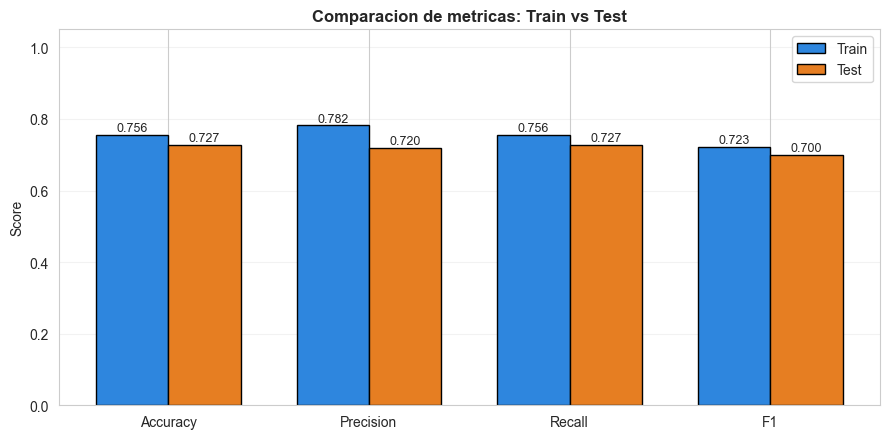

=== Resumen final Test ===
Accuracy : 0.7273
Precision: 0.7196
Recall   : 0.7273
F1       : 0.7002


In [16]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']
train_vals = [m_train[m] for m in metric_names]
test_vals = [m_test[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 4.5))
b1 = ax.bar(x - width/2, train_vals, width, label='Train', color='#2e86de', edgecolor='black')
b2 = ax.bar(x + width/2, test_vals, width, label='Test', color='#e67e22', edgecolor='black')

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparacion de metricas: Train vs Test', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

print('=== Resumen final Test ===')
print(f'Accuracy : {m_test["Accuracy"]:.4f}')
print(f'Precision: {m_test["Precision"]:.4f}')
print(f'Recall   : {m_test["Recall"]:.4f}')
print(f'F1       : {m_test["F1"]:.4f}')

### Interpretacion final (segun resultados obtenidos)
En este modelo se clasifica cada vivienda como **Barata (0), Media (1) o Cara (2)**.

Con los resultados de **Test** obtenidos:
- **Accuracy = 0.7273**
- **Precision = 0.7196**
- **Recall = 0.7273**
- **F1 = 0.7002**

la interpretacion es que el modelo tiene un rendimiento **bueno/aceptable** para decidir si una casa es barata, media o cara.

Ademas, la brecha de generalizacion fue baja:
- **Train - Test en Accuracy = 0.0283**
- Diagnostico: **buena generalizacion**, sin sobreajuste relevante.

En separacion por clase (ROC/AUC en Test):
- **Bajo (0): 0.9431**
- **Medio (1): 0.8114**
- **Alto (2): 0.9540**
- **AUC macro: 0.9028** | **AUC weighted: 0.9036**

Esto indica que el modelo distingue muy bien las casas **baratas** y **caras**, y que la clase **media** es la mas dificil (AUC menor), lo cual es consistente con que suele estar entre ambos extremos de precio.

Conclusion: para este cuaderno, el clasificador es util y razonablemente confiable para categorizar viviendas por nivel de precio, con margen de mejora principalmente en la clase **Media**.